## Topic 1: Introduction to RNN Architectures & The Four Types

---

### 1. Introduction

**What are RNN architectures?**
RNNs (Recurrent Neural Networks) are not a one-size-fits-all model. Depending on your problem, you can structure the network differently based on **what you feed as input** and **what you expect as output**.

**Why is this important?**
Different applications need different input-output patterns:
- Some tasks take **sequential input** and give a **single output** (e.g., sentiment analysis)
- Some take a **single input** and generate a **sequence** (e.g., image captioning)
- Some take **sequences** and give **sequences** (e.g., machine translation)

**Real-life use:**
- Google Translate (sequence → sequence)
- Sentiment analysis on product reviews (sequence → single value)
- Image captioning (single image → sequence of words)

---

### 2. Detailed Explanation

The core idea is simple: **RNNs process sequences step-by-step**, but how they are connected determines what they can do.

> **Key Concept:** The four architectures are categorized based on:
> - **Input type:** Is it sequential (many time steps) or non-sequential (one time step)?
> - **Output type:** Is it sequential (many time steps) or non-sequential (one time step)?

---

#### Architecture 1: **Many-to-One** (Sequence Input → Single Output)
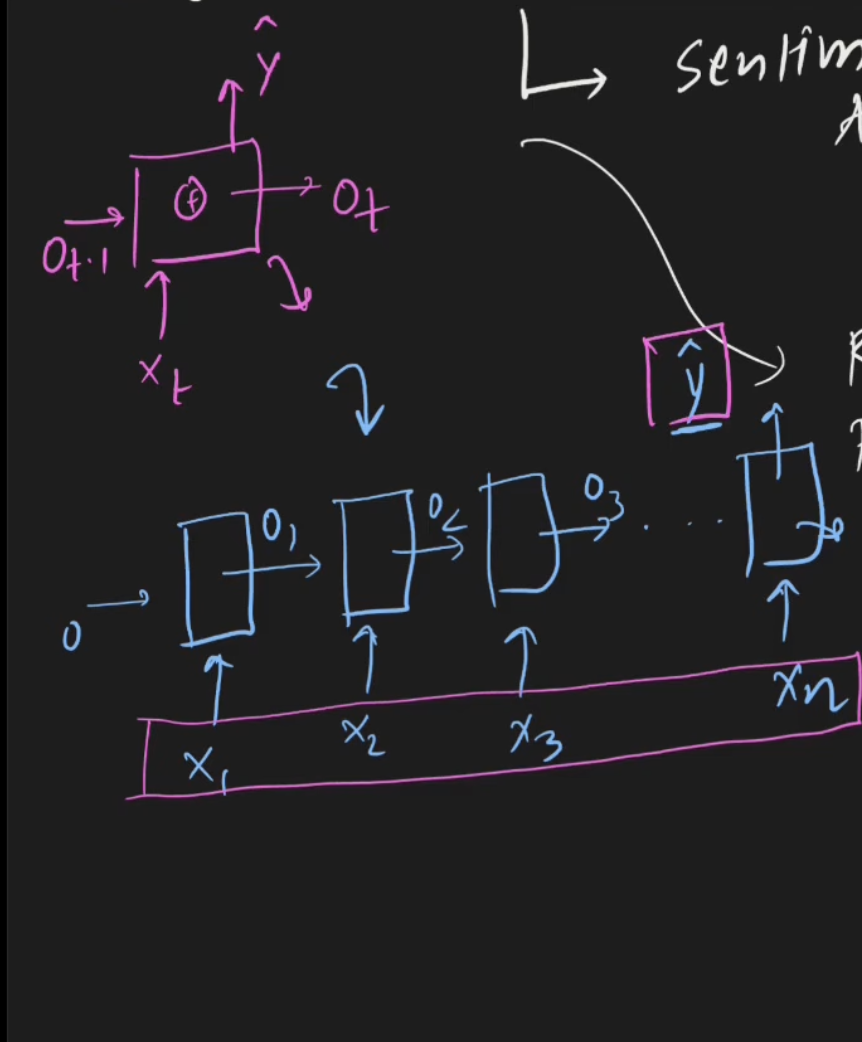
| Aspect | Description |
|--------|-------------|
| **Input** | Sequence of data (e.g., words in a sentence) |
| **Output** | A single value or class (e.g., positive/negative sentiment) |
| **Other names** | Also called "1 to 1" in some contexts (referring to final output) |

**How it works:**
- Each time step receives one element of the sequence (e.g., one word)
- The RNN processes step-by-step, passing hidden states forward
- **Only the output from the final time step** is used for prediction

**Example: Sentiment Analysis**
- Input: "This movie was amazing" → feed word by word
- Output: `1` (positive) or `0` (negative) after processing the entire sentence

**Other applications:**
- Movie rating prediction (1–5 stars from a review)
- Spam detection (email text → spam/not spam)

---

#### Architecture 2: **One-to-Many** (Single Input → Sequence Output)
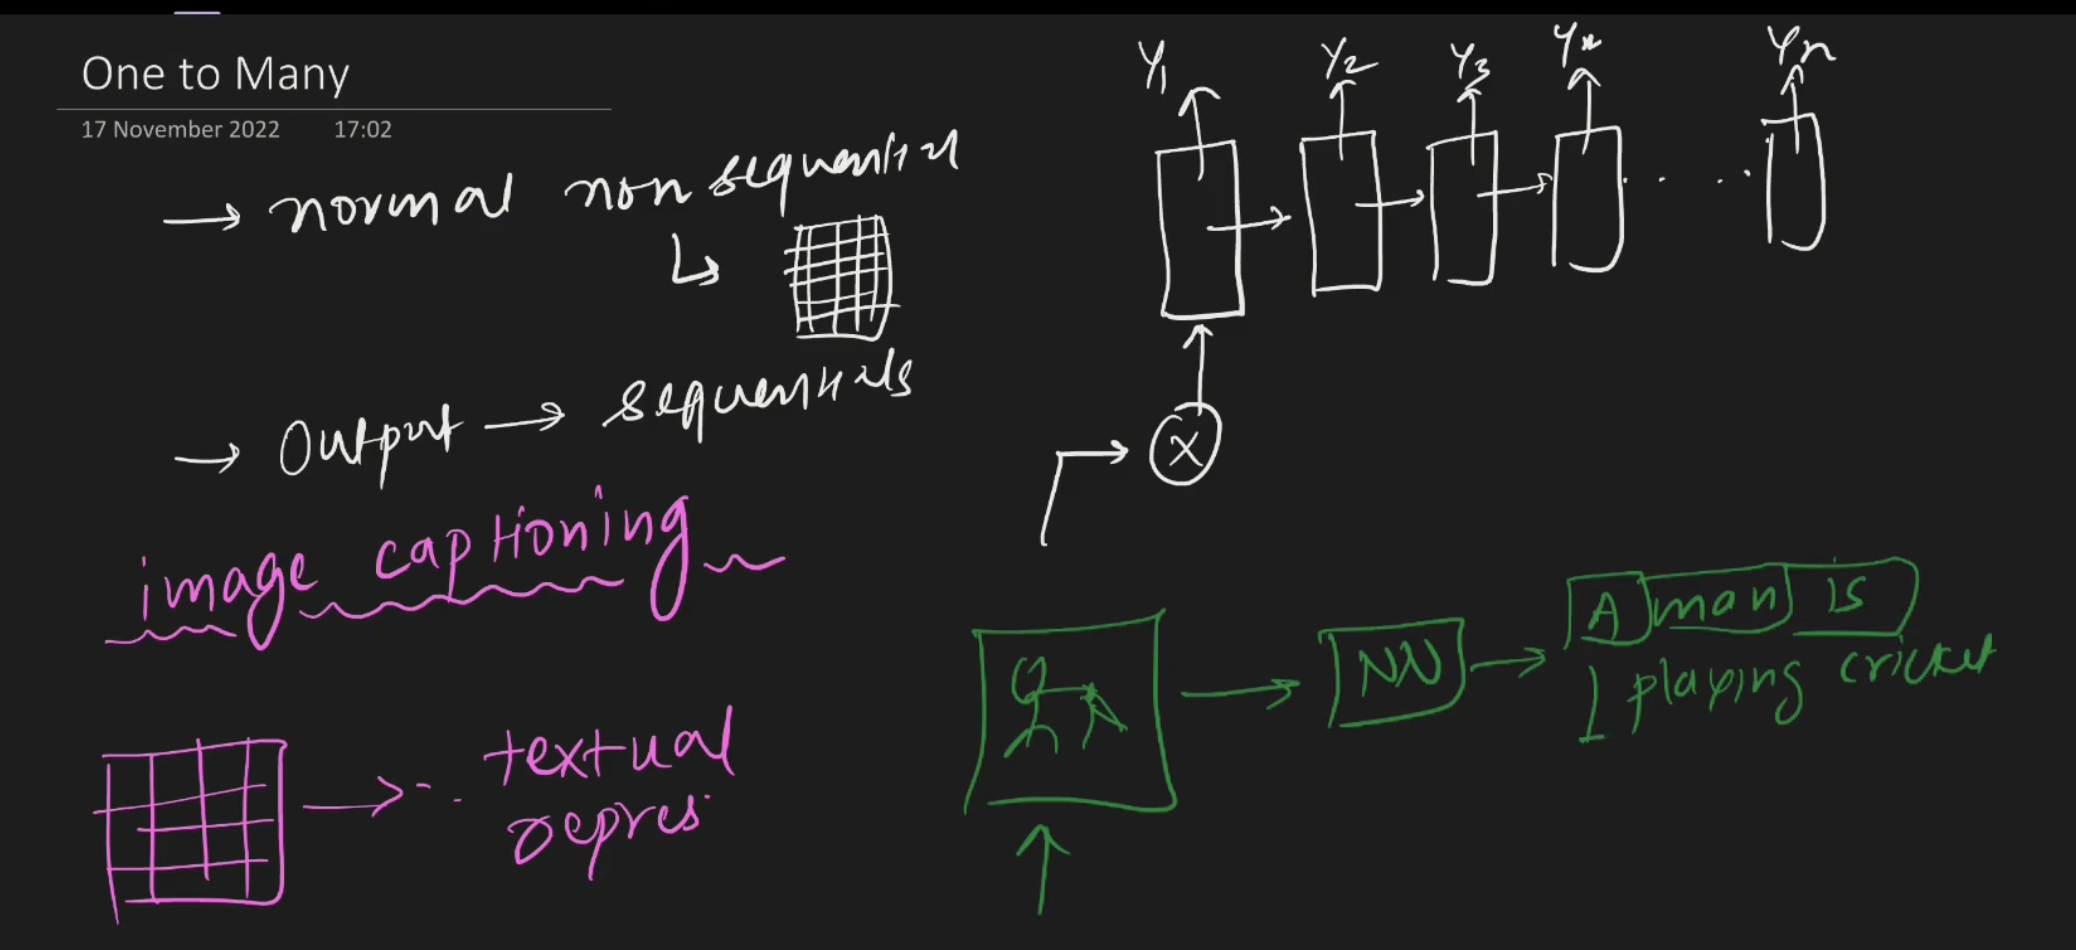
| Aspect | Description |
|--------|-------------|
| **Input** | Non-sequential, single data point (e.g., an image) |
| **Output** | Sequence of data (e.g., words describing the image) |
| **Other names** | Sometimes called "1 to n" |

**How it works:**
- You feed the input **once** at the first time step
- The RNN then generates outputs at **every subsequent time step**
- Each output feeds back into the network to help generate the next output

**Example: Image Captioning**
- Input: A single image (non-sequential)
- Output: "A man playing cricket" → generated word by word

**Other applications:**
- Music generation (input a genre/style → generate a sequence of musical notes)
- Text generation from a prompt

---

#### Architecture 3: **Many-to-Many** (Sequence Input → Sequence Output)

This is the most interesting and flexible type. It has **two subtypes** based on sequence lengths.

| Subtype | Description |
|---------|-------------|
| **Length Equal** | Input sequence length = Output sequence length |
| **Variable Length** | Input and output sequence lengths differ |

**How it works (Length Equal):**
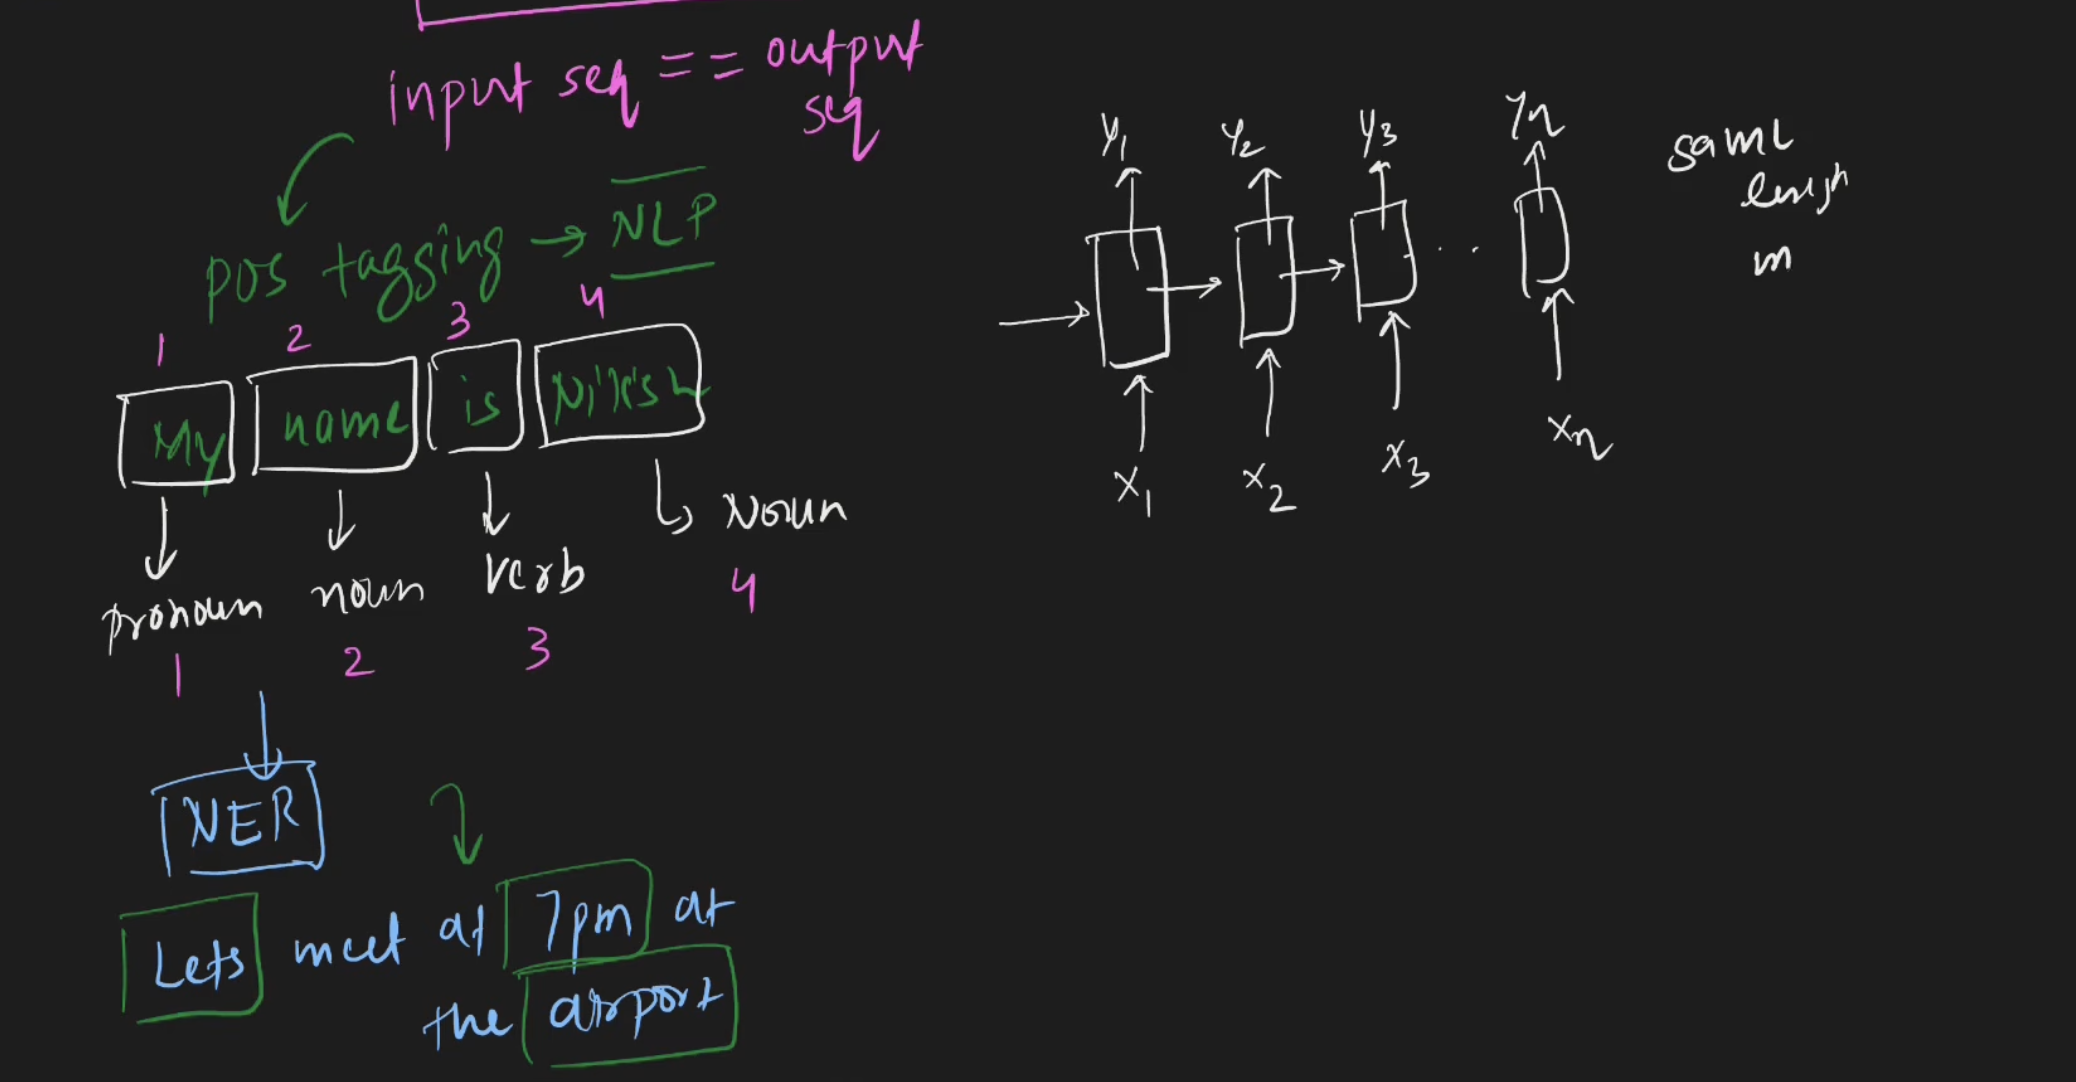
- Each time step receives an input **and** produces an output simultaneously
- This is like labeling each element of the input

**Example: Name Entity Recognition (NER)**
- Input: "Meet me at 7 PM at the airport"
- Output: For each word, predict if it's an entity (person, time, place) or not
- Word-by-word labeling

**How it works (Variable Length / Sequence-to-Sequence):**
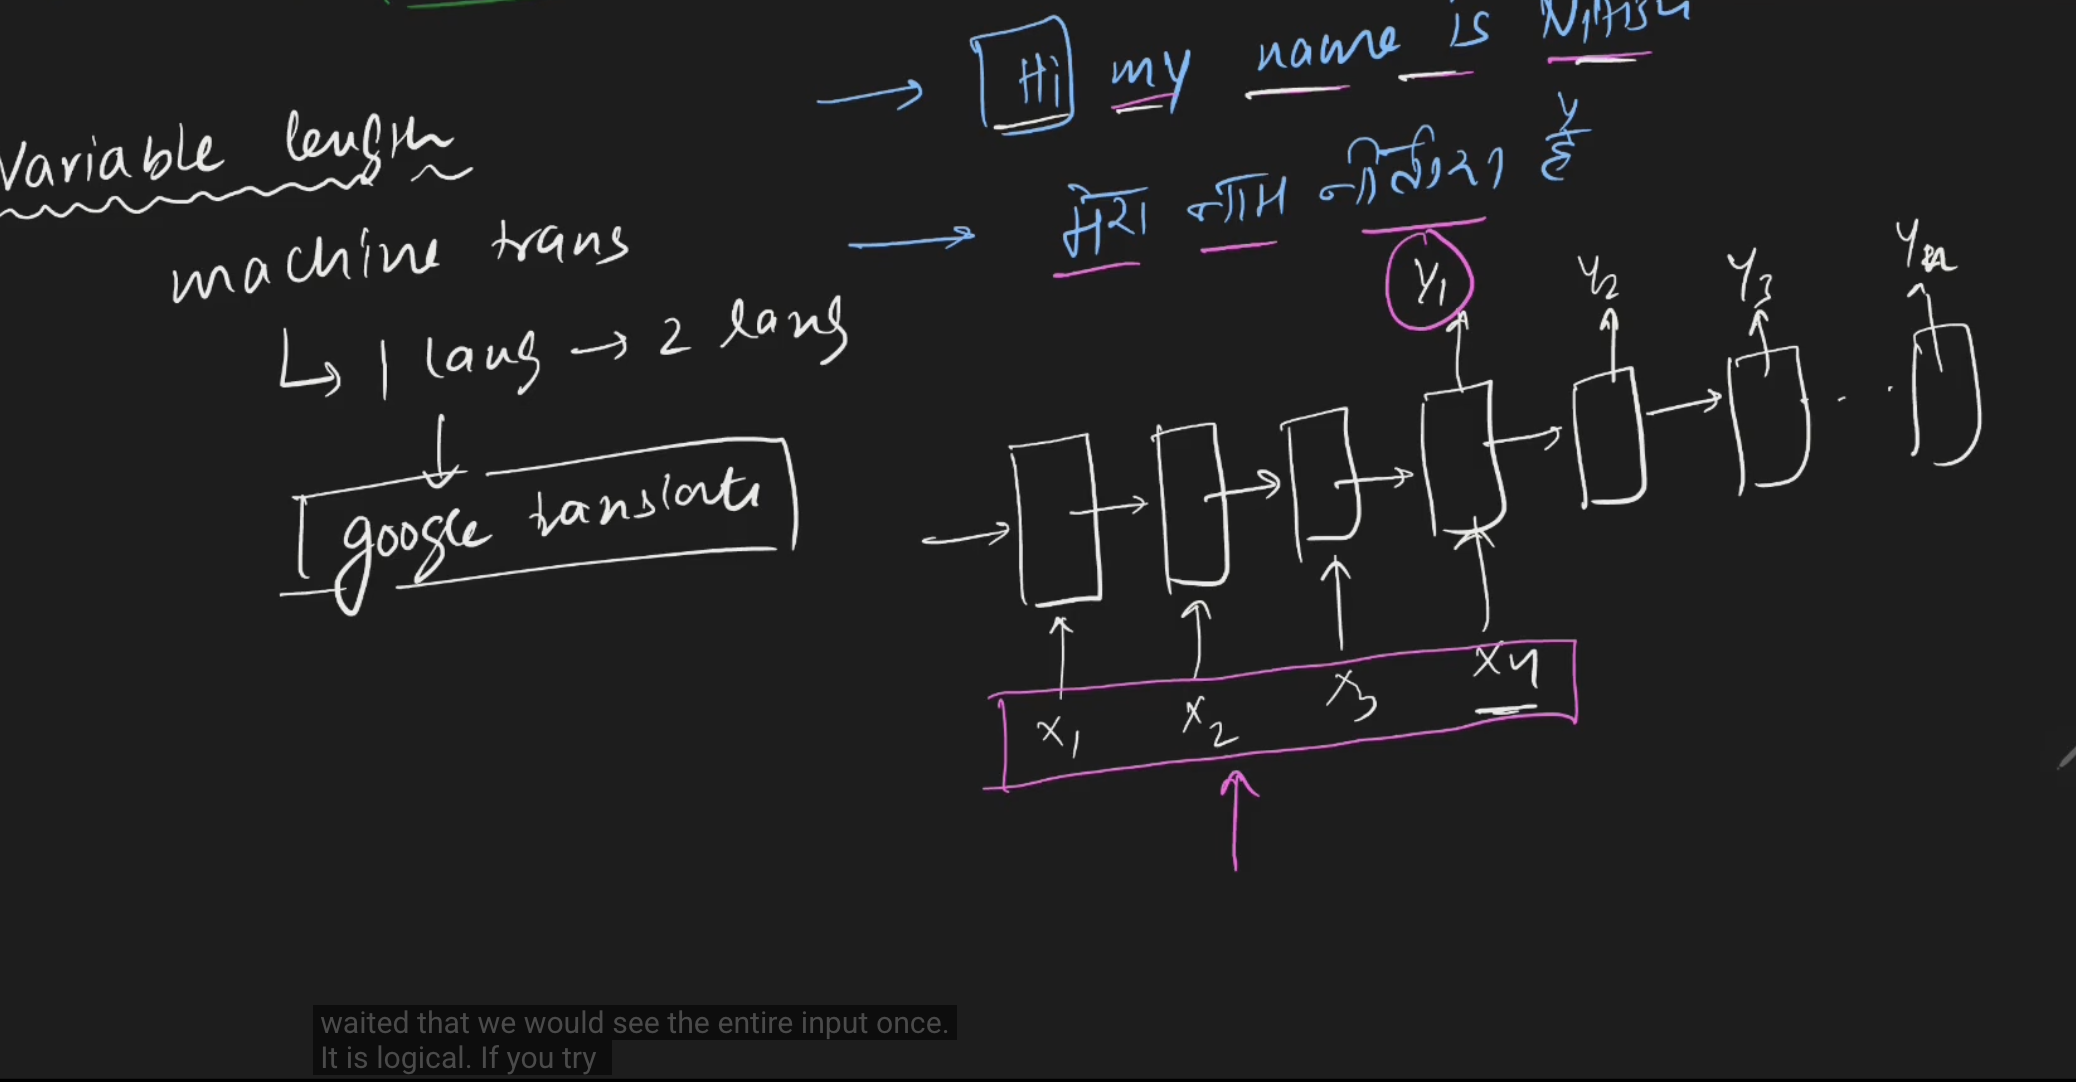
- You feed the **entire input sequence first** without generating outputs
- Once all inputs are processed, you start generating outputs
- This is called **Encoder-Decoder** architecture
  - **Encoder:** Part that reads the input
  - **Decoder:** Part that generates the output

**Example: Machine Translation**
- Input (English): "My name is Nitish" → 4 words
- Output (Hindi): "मेरा नाम नितीश है" → 4 words (can be different counts in other cases)
- The network **waits** until it sees the whole sentence before translating
- Why? Because translation requires understanding the full context and grammar, not just word-by-word translation

> **Why not translate word-by-word?**
> If you translated each word as you read it, you would lose grammatical meaning and context. A full sentence needs to be understood as a whole before translating.

---

#### Architecture 4: **One-to-One** (Single Input → Single Output)
(Not really RNN)
| Aspect | Description |
|--------|-------------|
| **Input** | Non-sequential (e.g., a single image) |
| **Output** | Non-sequential (e.g., a single class label) |
| **Reality** | This isn't really an RNN—it's a **standard neural network** or CNN |

**How it works:**
- No recurrence, no time steps
- Just a simple feedforward network

**Example: Image Classification**
- Input: Image of a cat
- Output: 1 (cat) or 0 (not cat)

The video mentions that technically this falls under simple neural networks or CNNs, not RNNs, but it's included for completeness.

---

### 3. Key Points

- RNN architectures are defined by **input-output relationships**
- The four types cover all combinations: many-to-one, one-to-many, many-to-many, one-to-one
- **Many-to-many** splits into:
  - Equal length (input size = output size)
  - Variable length (input size ≠ output size)
- **Encoder-Decoder** is the variable-length many-to-many architecture used in translation
- One-to-one isn't really an RNN—it's a basic neural network
- The architecture you choose **directly affects which applications** you can solve

---

### 4. Quick Comparison Table

| Architecture | Input Type | Output Type | Example Application | Is it RNN? |
|--------------|------------|-------------|---------------------|------------|
| Many-to-One | Sequence | Single value | Sentiment Analysis, Rating Prediction | ✅ Yes |
| One-to-Many | Single value | Sequence | Image Captioning, Music Generation | ✅ Yes |
| Many-to-Many (Equal) | Sequence | Sequence (same length) | Name Entity Recognition | ✅ Yes |
| Many-to-Many (Variable) | Sequence | Sequence (diff length) | Machine Translation (Encoder-Decoder) | ✅ Yes |
| One-to-One | Single value | Single value | Image Classification | ❌ No (CNN/FFNN) |

---

### 7. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|---------------|--------------|
| Using many-to-one for image captioning | Image is non-sequential input, but you need sequence output → should use **one-to-many** | Always check if your input has a temporal/sequential order |
| Translating word-by-word | You lose context and grammar | Wait for the **full sentence** before generating output (use variable-length many-to-many) |
| Thinking one-to-one is an RNN | There's no recurrence or time steps → it's just a feedforward network | An RNN must have some feedback loop or hidden state passed across time |
| Confusing equal vs variable length | Not all many-to-many architectures are the same | Check if output length matches input length—if not, you need Encoder-Decoder |

---

### 8. Interview/Exam Questions

**Q1: What are the four types of RNN architectures? Give one application for each.**
- Many-to-One: Sentiment analysis
- One-to-Many: Image captioning
- Many-to-Many (equal length): Name entity recognition
- Many-to-Many (variable length): Machine translation
- One-to-One: Image classification (not actually RNN)

**Q2: Why is machine translation an example of many-to-many (variable length) and not many-to-one?**
Because you need a **sequence output** (translated sentence) from a **sequence input** (source sentence), and the output length may differ from the input length.

**Q3: What is the Encoder-Decoder architecture and where is it used?**
Encoder reads the entire input sequence; Decoder generates the output sequence. Used in variable-length many-to-many tasks like machine translation.

**Q4: Why can't we just translate a sentence word-by-word?**
Because translation requires understanding the full context, grammar, and meaning of the whole sentence. Word-by-word translation loses this.

---

### 9. Revision Notes

- **Many-to-One:** Input is a sequence → output is a single value (e.g., sentiment)
- **One-to-Many:** Input is a single item → output is a sequence (e.g., captioning)
- **Many-to-Many (equal):** Input and output sequences are same length (e.g., NER)
- **Many-to-Many (variable):** Input and output differ in length → Encoder-Decoder (e.g., translation)
- **One-to-One:** Not an RNN; just a standard network
- **Important:** Choose architecture based on whether your input and output are sequential or non-sequential and whether lengths match

---


## Topic 2: Detailed Architecture & Workflow of Each RNN Type

---

### 1. Introduction

Now that we know the *four types* of RNN architectures, let's dive deeper into **how each one actually works** under the hood. Understanding the flow of data—how inputs are fed, how hidden states are passed, and when outputs are produced—is crucial for implementing these models correctly.

**Why this matters:**
- You can't just "plug in" an RNN—you need to structure it correctly for your problem
- The way you connect time steps determines whether your model learns properly
- This understanding is the foundation for backpropagation (next topic)

---

### 2. Detailed Explanation

Let's break down each architecture step-by-step with visual explanations.

---

#### A. Many-to-One Architecture (Sequence → Single Output)

**Data Flow Diagram:**

```
Input:   x₁ → x₂ → x₃ → ... → xₙ
         ↓    ↓    ↓          ↓
RNN:    [h₁]→[h₂]→[h₃]→...→[hₙ]
         ↓    ↓    ↓          ↓
Output:  -    -    -    ...   yₙ (ONLY final output used)
```

**Step-by-step process:**

1. **Time step 1:** Input `x₁` (first word) goes into the RNN block → produces hidden state `h₁`
2. **Time step 2:** Input `x₂` (second word) + previous hidden state `h₁` → produces `h₂`
3. **Time step 3:** Input `x₃` + `h₂` → produces `h₃`
4. ...continues for all time steps
5. **Final time step (n):** Input `xₙ` + `hₙ₋₁` → produces `hₙ` → **this is the only output we use**

**Why ignore intermediate outputs?**
Because the final hidden state contains a "summary" of the entire sequence. Each intermediate state only has partial information.

**Real-world example - Movie Rating Prediction:**
- Input: "The acting was superb and the plot was thrilling" (feed word by word)
- Final hidden state captures the overall sentiment
- Output: 5 stars (single number)

---

#### B. One-to-Many Architecture (Single Input → Sequence Output)

**Data Flow Diagram:**

```
Input:   x (single input, fed only at t₁)
         ↓
RNN:    [h₁] → [h₂] → [h₃] → ... → [hₙ]
         ↓      ↓      ↓            ↓
Output:  y₁     y₂     y₃    ...   yₙ (ALL outputs used)
         ↑      ↑      ↑            ↑
         └──────┘──────┘────────────┘ (feedback loop)
```

**Step-by-step process:**

1. **Time step 1:** Feed the single input `x` (e.g., an image) → produces hidden state `h₁` and output `y₁` (first word of caption)
2. **Time step 2:** Use `y₁` (or the hidden state from t₁) as the "input" for the next time step → produces `h₂` and `y₂`
3. **Time step 3:** Use `y₂` → produces `h₃` and `y₃`
4. Continues until the desired sequence length is reached

**Key insight:** After the first step, the network is essentially "self-feeding"—each output becomes the input for the next step.

**Real-world example - Image Captioning:**
- Input: Image of a man playing cricket (non-sequential, single input)
- t₁: Generate "A"
- t₂: Generate "man" (using "A" as context)
- t₃: Generate "playing" (using "man" as context)
- t₄: Generate "cricket" (using "playing" as context)
- Output: "A man playing cricket"

---

#### C. Many-to-Many (Equal Length) Architecture

**Data Flow Diagram:**

```
Input:   x₁ → x₂ → x₃ → ... → xₙ
         ↓    ↓    ↓          ↓
RNN:    [h₁]→[h₂]→[h₃]→...→[hₙ]
         ↓    ↓    ↓          ↓
Output:  y₁   y₂   y₃   ...  yₙ (ALL outputs used)
```

**Step-by-step process:**

1. **Time step 1:** Input `x₁` → output `y₁` (label for first word)
2. **Time step 2:** Input `x₂` + `h₁` → output `y₂` (label for second word)
3. ...continues for all words
4. **Time step n:** Input `xₙ` + `hₙ₋₁` → output `yₙ` (label for last word)

**Key difference from Many-to-One:** Every time step produces an output that we actually use for prediction, not just the final one.

**Real-world example - Name Entity Recognition (NER):**
```
Input:  "Meet"  "me"   "at"   "7 PM"   "at"   "the"   "airport"
         ↓       ↓      ↓      ↓        ↓      ↓        ↓
Output: O       O      O      TIME     O      O       LOCATION
```
(O = not an entity, TIME = time entity, LOCATION = place entity)

---

#### D. Many-to-Many (Variable Length / Encoder-Decoder)

**Data Flow Diagram:**

```
ENCODER (Reads input):          DECODER (Generates output):
                               
Input:   x₁ → x₂ → x₃ → x₄     (no inputs here)
         ↓    ↓    ↓    ↓
RNN:    [h₁]→[h₂]→[h₃]→[h₄]   [h₄] → [h₅] → [h₆] → [h₇]
         ↓    ↓    ↓    ↓        ↓      ↓      ↓      ↓
Output:  -    -    -    -        y₁     y₂     y₃     y₄ (ALL outputs used)
                              (start   (trans-  (trans-  (trans-
                              gener-   lation   lation   lation)
                              ating)   word1)   word2)   word3)
```

**Step-by-step process:**

**Encoder Phase (no outputs produced):**
1. Feed `x₁` → produces `h₁`
2. Feed `x₂` + `h₁` → produces `h₂`
3. Feed `x₃` + `h₂` → produces `h₃`
4. Feed `x₄` + `h₃` → produces `h₄` (final hidden state)
5. The final hidden state `h₄` acts as a **context vector**—it captures the meaning of the entire input sentence

**Decoder Phase (no inputs fed):**
6. Take `h₄` as the starting hidden state
7. Start generating outputs one by one
8. Each output feeds back to help generate the next

**Why wait to produce outputs?**
The encoder first understands the **full context** of the sentence. Only after reading everything does the decoder start translating. This preserves grammar and meaning.

**Real-world example - Machine Translation:**
- Input (English): "My name is Nitish" → 4 words
- Encoder reads all 4 words
- Decoder generates: "मेरा" → "नाम" → "नितीश" → "है"
- Notice: Output length equals input length here, but in other cases (e.g., "I love you" → "Ich liebe dich" in German), lengths can differ

---

#### E. One-to-One Architecture (The "Non-RNN")

**Data Flow Diagram:**

```
Input:   x (single, non-sequential)
         ↓
NN:     [Neural Network]
         ↓
Output:  y (single, non-sequential)
```

**Step-by-step process:**
1. Single input is passed through a standard neural network
2. No time steps, no hidden state passing
3. Single output is produced

**Real-world example - Image Classification:**
- Input: Image (converted to pixel values)
- Output: 1 (cat) or 0 (not cat)

**Important note:** This is technically **not** an RNN because there's no recurrence. The video includes it just to complete the spectrum of input-output combinations.

---

### 3. Key Points

- **Many-to-One:** All time steps pass hidden states forward; only the **final output** is used
- **One-to-Many:** The **first time step** receives the input; subsequent steps use their own previous outputs
- **Many-to-Many (Equal):** Each time step receives input AND produces an output simultaneously
- **Many-to-Many (Variable):** Split into **Encoder** (reads all inputs) and **Decoder** (generates all outputs)
- The **hidden state** is the memory that carries information across time steps
- The architecture is defined by **when and how** inputs are fed and outputs are taken

---

### 4. Comparison of Architectures (At-a-Glance)

| Architecture | Input Timing | Output Timing | Hidden State Usage |
|--------------|--------------|---------------|-------------------|
| Many-to-One | Fed at every step | Only final step | Passed through all steps |
| One-to-Many | Only first step | Every step | Passed through all steps; outputs feed back |
| Many-to-Many (Equal) | Fed at every step | Every step | Passed through all steps |
| Many-to-Many (Variable) | Fed at every step in encoder | Only in decoder phase | Final encoder state passed to decoder |
| One-to-One | Single feed | Single output | No hidden state |

---

### 7. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|---------------|--------------|
| Using all intermediate outputs in many-to-one | Intermediate states don't have full sequence context | Only use the **final time step** output |
| Feeding inputs at every step in one-to-many | This architecture expects a single, non-sequential input | Feed the input **only once**, at t₁ |
| Not feeding previous output back in one-to-many | The network needs its own generated words to continue the sequence | Always connect output → next input |
| Forgetting the encoder-decoder split in variable length | You can't generate outputs before reading the full input | Complete encoding phase first, then start decoding |
| Treating one-to-one as an RNN | There's no recurrence, no time steps | Recognize it as a standard feedforward network |

---

### 8. Interview/Exam Questions

**Q1: In a many-to-one RNN for sentiment analysis, why don't we use the outputs from intermediate time steps?**
Because intermediate outputs only have information about the words seen so far. The final hidden state captures the entire sequence context, making it the best representation for the whole sentence.

**Q2: How does a one-to-many RNN generate a sequence without receiving inputs at each time step?**
After the first time step, the network uses its **own previous output** as the input for the next time step. This creates a self-feeding loop that generates the sequence.

**Q3: What is the purpose of the encoder in a variable-length many-to-many architecture?**
The encoder reads and processes the entire input sequence to create a **context vector** (final hidden state) that captures the complete meaning. This context vector then initializes the decoder for generating the output.

**Q4: Can you use the same architecture for sentiment analysis and machine translation? Why or why not?**
No. Sentiment analysis is many-to-one (sequence → single value), while machine translation is many-to-many (sequence → sequence). They have different input-output requirements.

**Q5: Why does the decoder in machine translation only start producing outputs after the encoder has processed all inputs?**
Translating requires understanding the **full sentence**—its grammar, context, and meaning. If you translated word-by-word, you'd lose this context and produce poor translations.

---

### 9. Revision Notes

- **Many-to-One:** Final output only → use for classification/rating
- **One-to-Many:** Self-feeding outputs → use for generation (captions, music)
- **Many-to-Many (Equal):** Simultaneous in-out → use for labeling each element (NER)
- **Many-to-Many (Variable):** Encoder reads → Decoder writes → use for translation
- **One-to-One:** No recurrence → this is a CNN/standard NN
- **Hidden State:** The "memory" that carries information forward in all true RNN architectures
- **Encoder-Decoder:** Two-part system—encoder understands input, decoder generates output

---



## Topic 3: Practical Applications & Choosing the Right Architecture

---

### 1. Introduction

Now that we understand the four architectures and how they work, the next logical question is: **Which architecture should I use for my problem?**

This topic bridges theory and practice by walking through real applications, explaining *why* a particular architecture fits, and helping you develop the intuition to make the right choice.

**Why this matters:**
- In real-world projects, you won't be told "use a many-to-many RNN"—you'll have a problem and need to map it to the correct architecture
- Using the wrong architecture means your model simply won't learn the task
- This skill separates theoretical knowledge from practical implementation ability

---

### 2. Detailed Explanation

The decision always comes down to three questions:

1. **Is my input sequential?** (Does it have an order/temporal dimension?)
2. **Is my output sequential?** (Do I need multiple outputs over time?)
3. **If both are sequential, are they the same length?**

Let's explore each application from the video and see why a particular architecture was chosen.

---

#### Application 1: Sentiment Analysis

**Problem Statement:**
Given a text review (e.g., "The movie was fantastic"), predict whether the sentiment is positive or negative.

| Question | Answer |
|----------|--------|
| Input type? | **Sequential** (words have order—you can't shuffle them) |
| Output type? | **Single value** (positive/negative or rating 1-5) |
| Architecture chosen: | **Many-to-One** |

**Why Many-to-One?**
- You need to understand the **entire sentence** before making a judgment
- Each word contributes context, but the final output is a single decision
- The RNN processes all words and the **final hidden state** summarizes the overall sentiment

**Real-world variations:**
- Binary classification: Positive vs. Negative
- Multi-class: 1-star to 5-star ratings
- Multi-label: Happy, Sad, Angry, Neutral

**Implementation Flow:**
```
Input Sequence: "The" → "movie" → "was" → "fantastic"
                      ↓         ↓         ↓          ↓
RNN Processing:      h₁ →      h₂ →      h₃ →      h₄
                      ↓         ↓         ↓          ↓
Output:               -         -         -     [Prediction: Positive]
```

---

#### Application 2: Rating Prediction

**Problem Statement:**
Given a product review, predict the number of stars (1-5) the user would give.

| Question | Answer |
|----------|--------|
| Input type? | **Sequential** (review text) |
| Output type? | **Single value** (1 to 5) |
| Architecture chosen: | **Many-to-One** |

**Same as Sentiment Analysis but with a different output range:**
- Instead of [0,1] binary, output is [1,2,3,4,5]
- This is a **regression** (or ordinal classification) problem
- The final hidden state feeds into a dense layer with 5 outputs or a single neuron predicting the rating

---

#### Application 3: Image Captioning

**Problem Statement:**
Given an image, generate a textual description (caption) of what's happening in it.

| Question | Answer |
|----------|--------|
| Input type? | **Non-sequential** (image is spatial, not temporal) |
| Output type? | **Sequential** (words in the caption) |
| Architecture chosen: | **One-to-Many** |

**Why One-to-Many?**
- The input is a single image—no time steps
- But the output is a sequence of words—needs multiple time steps
- The RNN sees the image once (at t₁) and then generates one word at a time

**How it actually works in practice (simplified):**
1. Pass the image through a CNN to get a feature vector (e.g., 2048 numbers)
2. Feed this vector as the input at t₁ of the RNN
3. t₁ output: First word (e.g., "A")
4. t₂: Use "A" to predict "man"
5. t₃: Use "man" to predict "playing"
6. t₄: Use "playing" to predict "cricket"

**Implementation Note:**
Image captioning actually uses a CNN + RNN hybrid (CNN for image features, RNN for sequence generation). The video simplifies this to illustrate the architecture concept.

---

#### Application 4: Music Generation

**Problem Statement:**
Generate a sequence of musical notes (melody) given a starting note or genre.

| Question | Answer |
|----------|--------|
| Input type? | **Non-sequential** (starting note or genre) |
| Output type? | **Sequential** (notes over time) |
| Architecture chosen: | **One-to-Many** |

**Why One-to-Many?**
- You provide a single starting condition
- The RNN then continuously generates notes one after another
- Each generated note feeds back as input for the next note

**Interesting twist:**
- In practice, you might use a **many-to-many** variant where you input a sequence of previous notes to predict the next note (like a language model for music)
- But the pure one-to-many architecture is used when you want to generate from scratch

---

#### Application 5: Name Entity Recognition (NER)

**Problem Statement:**
Given a sentence, label each word as an entity (Person, Organization, Location, Time, etc.) or not.

| Question | Answer |
|----------|--------|
| Input type? | **Sequential** (words in sentence) |
| Output type? | **Sequential** (label for each word) |
| Do input and output lengths match? | **Yes** (one label per word) |
| Architecture chosen: | **Many-to-Many (Equal Length)** |

**Why Equal Length Many-to-Many?**
- You need an output at every time step (label each word)
- Each output corresponds directly to its input
- The lengths match perfectly: 5 words → 5 labels

**Example:**
```
Input:    "Meet"  "me"  "at"  "7 PM"  "at"  "the"  "airport"
          ↓       ↓     ↓     ↓       ↓     ↓      ↓
Output:   O       O     O     TIME    O     O      LOCATION
```

**Common entity tags:**
- O = Outside (not an entity)
- PERSON = Person name
- ORG = Organization
- LOC = Location
- TIME = Time expression
- DATE = Date expression

---

#### Application 6: Machine Translation

**Problem Statement:**
Translate a sentence from one language to another (e.g., English → Hindi, English → German).

| Question | Answer |
|----------|--------|
| Input type? | **Sequential** (source sentence) |
| Output type? | **Sequential** (translated sentence) |
| Do input and output lengths match? | **Not guaranteed** (different languages have different efficiencies) |
| Architecture chosen: | **Many-to-Many (Variable Length)** |

**Why Variable Length Many-to-Many?**
- You need to read the **entire** source sentence before translating
- The output length may differ—some languages express ideas in fewer words
- Example: "I love you" (3 words) → "Ich liebe dich" (3 words in German, but could be 2 in other languages)
- The **Encoder-Decoder** model is perfect here

**Why not translate word-by-word?**
```
Wrong approach (word-by-word):
"My" → "मेरा"
"name" → "नाम"
"is" → "है"
"Nitish" → "नितीश"
This loses grammar and sounds unnatural!

Correct approach (Encoder-Decoder):
Read: "My name is Nitish" → Understand the whole meaning → Generate: "मेरा नाम नितीश है"
```

**The Encoder-Decoder Process:**
1. **Encoder:** Reads all source words, compresses meaning into a context vector
2. **Context Vector:** A fixed-size representation of the entire sentence
3. **Decoder:** Uses the context vector to generate translated words one by one

**Real-world systems using this:**
- Google Translate
- DeepL
- Microsoft Translator

---

### 3. Key Points

- **Choice of architecture depends on three things:** Is input sequential? Is output sequential? Do lengths match?
- **Many-to-One:** Sequential input, single output → Use for classification, rating, sentiment
- **One-to-Many:** Single input, sequential output → Use for generation (captions, music)
- **Many-to-Many (Equal):** Both sequential, same length → Use for labeling, tagging (NER)
- **Many-to-Many (Variable):** Both sequential, different lengths → Use for translation, summarization
- **Encoder-Decoder** is the specific name for variable-length many-to-many

---

### 4. Decision Flowchart

```
START: What is your task?
          |
   Is your input sequential?
     /              \
    Yes              No
     |                |
   Is your output    Is your output
   sequential?      sequential?
    /     \           /     \
   Yes     No        Yes     No
    |       |         |       |
   Do       |    Use One-to-  Use One-to-One
   lengths  |    Many (e.g.,  (Not an RNN!
   match?   |    captioning)  e.g., image
    /  \    |                 classification)
   Yes  No  |
    |    |  |
Use Many- Use Many-
to-Many  to-Many
(Equal)  (Variable)
(e.g.,   (e.g.,
NER)     trans-
         lation)
```

---

### 7. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|---------------|--------------|
| Using many-to-one for translation | Translation needs sequence output, not single value | Check if your output is multiple items |
| Using one-to-many for NER | NER needs input at every time step (one word at a time) | One-to-many only receives input once |
| Assuming input and output lengths always match in many-to-many | Languages have different efficiencies | Always verify—use variable length if unsure |
| Using many-to-many (equal) for translation | Translation may have different word counts | Use Encoder-Decoder (variable length) instead |
| Thinking image classification is an RNN application | Images aren't sequential; it's a standard NN/CNN task | Only use RNNs when order/temporality matters |

---

### 8. Interview/Exam Questions

**Q1: You're building a system to predict the next word in a sentence. Which architecture would you use?**
This is a many-to-many (equal length) if you need a prediction for every position, or one-to-many if you're generating from a seed. For language modeling, it's typically many-to-many (each word predicts the next).

**Q2: Why is video captioning (generating captions for video frames) a one-to-many architecture?**
The input is a single video clip (non-sequential if summarized as a single feature vector), but the output is a sequence of words. This follows the one-to-many pattern.

**Q3: How would you handle summarization—where input is a long article and output is a short summary?**
This is many-to-many (variable length). The article is a sequence (many words), the summary is also a sequence, but lengths differ. You'd use Encoder-Decoder.

**Q4: What if a task has sequential input, sequential output, but sometimes lengths match and sometimes they don't?**
You must use the more flexible variable-length many-to-many (Encoder-Decoder) because it handles both cases. You can't use equal-length if there's any possibility of length mismatch.

**Q5: Can you use an RNN for image classification?**
Yes, but it's not necessary. Image classification is one-to-one (non-sequential input, non-sequential output). A standard CNN is simpler and more effective. Using an RNN would be overcomplicating the problem.

---

### 9. Revision Notes

- **Three questions determine architecture:**
  1. Is input sequential?
  2. Is output sequential?
  3. If yes to both, do lengths match?

- **Applications mapping:**
  - Sentiment Analysis → Many-to-One
  - Rating Prediction → Many-to-One
  - Image Captioning → One-to-Many
  - Music Generation → One-to-Many
  - Name Entity Recognition → Many-to-Many (Equal)
  - Machine Translation → Many-to-Many (Variable / Encoder-Decoder)
  - Image Classification → One-to-One (Not an RNN)

- **Key insight:** Don't memorize applications—instead, ask the three questions for any new task you encounter

- **Encoder-Decoder:** = Encoder (reads input) + Decoder (generates output); used when lengths can vary

---


## Topic 4: Next Steps – Backpropagation in RNNs (Preview)

---

### 1. Introduction

We have now covered the four RNN architectures and their real-world applications. But there's a critical question: **How do these networks actually learn?**

Just like standard neural networks, RNNs learn by:
1. Making predictions (forward pass)
2. Calculating errors (loss)
3. Updating weights to reduce errors (backward pass)

However, because RNNs have **time steps** and **shared weights**, the backward pass is significantly different. It's called **Backpropagation Through Time (BPTT)** .

**Why this matters:**
- Understanding how RNNs learn helps you debug training issues
- It explains common problems like vanishing gradients
- It's a classic interview question for deep learning roles

**Disclaimer:** The video mentions that backpropagation is the **next topic** to be covered. This section is a preview based on what was discussed in the transcript, not a full implementation guide.

---

### 2. Detailed Explanation

#### Why is Backpropagation Different for RNNs?

In a standard feedforward network:
- Error flows **backwards** through layers: Layer 3 → Layer 2 → Layer 1
- Each layer has its own weights that get updated

In an RNN:
- The same weights (W, U, V) are shared across **all time steps**
- Error must flow backwards through **both layers AND time steps**
- This means: Error at time t must propagate back to time t-1, t-2, ..., t-n

**Visual Analogy:**
Think of a sequence of dominoes falling forward (forward pass). To fix what went wrong, you need to trace the error back through every domino that fell. In RNNs, we unroll the network and backpropagate through each "unrolled" time step.

---

#### The Unrolling Concept

To apply backpropagation to RNNs, we **unroll** the network along the time dimension:

```
Original RNN:        Unrolled RNN:

     ┌───┐            x₁ → [RNN] → y₁
x → │RNN│→ y           ↓     ↑      ↑
     └───┘            x₂ → [RNN] → y₂
                       ↓     ↑      ↑
     (Recurrent)       x₃ → [RNN] → y₃
                       ↓     ↑      ↑
                       ...   ...    ...
                       xₙ → [RNN] → yₙ
```

After unrolling:
- The network looks like a **very deep feedforward network** with n layers
- Each "layer" corresponds to one time step
- But—**critical point**—the weights are **shared** across all these layers

---

#### Backpropagation Through Time (BPTT) - Conceptual Overview

**Step 1: Forward Pass**
1. Process the sequence from t=1 to t=n
2. Store all hidden states (h₁, h₂, ..., hₙ) and outputs (y₁, y₂, ..., yₙ)

**Step 2: Calculate Loss**
- Sum of losses at each time step (or only at the final step, depending on architecture)
- Total Loss = L₁ + L₂ + ... + Lₙ

**Step 3: Backward Pass (Backpropagation Through Time)**
1. Calculate gradient of loss with respect to the output at each time step
2. Propagate gradients **backwards through time** from t=n to t=1
3. At each time step, gradients from two sources combine:
   - Gradient from the **output** at that time step
   - Gradient from the **future** (hidden state at t+1)

**Step 4: Update Weights**
- Accumulate gradients across all time steps
- Update the shared weights once using the accumulated gradient

---

#### Why "Through Time"?

The "through time" part refers to the fact that errors from future time steps affect past time steps. For example:

- The prediction at time t=3 depends on the hidden state from t=2
- The hidden state from t=2 depends on the hidden state from t=1
- So the error at t=3 must flow back through t=2 to reach t=1

**Gradient Flow Example for Many-to-One (Sentiment Analysis):**
```
Error from yₙ (final output) flows:
     yₙ → hₙ → hₙ₋₁ → hₙ₋₂ → ... → h₁ → inputs
     ↑      ↑       ↑            ↑
     Error at each hidden state includes contribution from the future
```

---

#### Architectures and Backpropagation – A Preview

The video mentions that each architecture type requires a slightly different backpropagation approach:

| Architecture | How Backpropagation Works (Preview) |
|--------------|--------------------------------------|
| **Many-to-One** | Error only from the **final output** flows back through all time steps |
| **One-to-Many** | Errors from **all outputs** flow back; also need to handle the self-feeding mechanism |
| **Many-to-Many (Equal)** | Errors from **all outputs** flow back simultaneously |
| **Many-to-Many (Variable)** | Error from decoder outputs flows back; also need to propagate through the encoder-decoder connection |

**Key Insight:** The architecture determines **where** the error comes from and **how far** it needs to flow.

---

### 3. Key Points

- **Backpropagation Through Time (BPTT)** is the name for RNN backpropagation
- RNNs share weights across time steps—gradients must be accumulated
- The network is **unrolled** into a deep feedforward network for training
- Error from future time steps flows backward to earlier time steps
- Different architectures have different error flow patterns
- BPTT is computationally expensive for long sequences
- BPTT can suffer from vanishing/exploding gradients (a major challenge)

---

### 4. Common Challenges (Preview)

The video doesn't go into depth here, but these are standard RNN issues you'll encounter:

| Challenge | What It Is | Why It Happens |
|-----------|------------|----------------|
| **Vanishing Gradients** | Gradients become very small, weights don't update | Repeated multiplication of small numbers during backpropagation through many time steps |
| **Exploding Gradients** | Gradients become very large, training diverges | Repeated multiplication of large numbers |
| **Long-Term Dependencies** | Network can't remember information from far back | Vanishing gradients prevent early time steps from being updated |

**Solutions (to be covered in future topics):**
- Gradient clipping (for exploding gradients)
- LSTMs and GRUs (for vanishing gradients)
- Truncated BPTT (only backpropagate for a fixed number of time steps)

---

### 8. Interview/Exam Questions (Preview)

**Q1: What does BPTT stand for and what does it do?**
Backpropagation Through Time – it's the algorithm for training RNNs by unrolling them through time and applying standard backpropagation.

**Q2: Why can't we just use standard backpropagation on RNNs?**
Because RNNs share weights across time steps, and the error from future time steps must be propagated back through previous time steps. Standard backpropagation doesn't account for this temporal dependency.

**Q3: What is the difference between backpropagation in a CNN and BPTT in an RNN?**
CNN backpropagation goes backward through spatial layers. BPTT goes backward through **both layers AND time steps**, with the same weights being updated based on gradients accumulated across all time steps.

**Q4: Why does BPTT have a "through time" in its name?**
Because errors propagate not just through layers, but also through the temporal dimension—from future time steps back to past time steps.

**Q5: Why does the architecture type matter for backpropagation?**
Because different architectures produce errors at different time steps (e.g., only final output vs. all outputs), so the direction and flow of gradients change accordingly.

---

### 9. Revision Notes

- **BPTT** = Backpropagation Through Time
- **Unrolling** = Expanding an RNN into a deep network across time steps
- **Shared Weights** = Same weights are used at every time step; gradients are summed
- **Gradient Flow** = Error from future steps flows backward through time
- **Two Sources of Gradients** at each hidden state: output error + future hidden state error
- **Architecture Impact:** Different architectures (many-to-one, one-to-many, etc.) have different error sources
- **Next Steps:** Future videos will cover BPTT in detail for each architecture type

---

### Complete Summary of All Topics Covered

| Topic | Key Takeaway |
|-------|--------------|
| **Four Types of RNNs** | Many-to-One, One-to-Many, Many-to-Many (Equal & Variable), One-to-One |
| **Architecture Workflow** | How inputs are fed, when outputs are produced, and how hidden states flow |
| **Applications & Selection** | Map real-world problems to architectures using three questions |
| **Backpropagation Preview** | BPTT is how RNNs learn; involves unrolling through time |

---

**This concludes all topics from the transcript. We've covered:**

1. ✅ The four RNN architectures and their characteristics
2. ✅ Detailed workflow of each architecture
3. ✅ Real-world applications and how to choose the right architecture
4. ✅ Preview of backpropagation (BPTT) and what's coming next



**You've now completed all topics from the transcript!**